# Experiment 4: Binary Classification using Linear and Kernel-Based Models
**ICS1512 - Machine Learning Algorithms Laboratory**

Classifying emails as spam/ham using Logistic Regression and SVM, with hyperparameter tuning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set_style("whitegrid")
%matplotlib inline

## 1. Load Dataset

In [4]:
df = pd.read_csv("spambase_csv.csv")
print(df.shape)
df.head()

(4601, 58)


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


## 2. Exploratory Data Analysis

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

In [6]:
# check for missing values
df.isnull().sum().sum()

np.int64(0)

In [7]:
def eda_summary(data, target_col):
    print("Shape:", data.shape)
    print("\nMissing values:\n", data.isnull().sum().sum())
    print("\nClass distribution:\n", data[target_col].value_counts())
    print("\nBasic stats:\n", data.describe().T.head())

eda_summary(df, "class")

Shape: (4601, 58)

Missing values:
 0

Class distribution:
 class
0    2788
1    1813
Name: count, dtype: int64

Basic stats:
                     count      mean       std  min  25%  50%   75%    max
word_freq_make     4601.0  0.104553  0.305358  0.0  0.0  0.0  0.00   4.54
word_freq_address  4601.0  0.213015  1.290575  0.0  0.0  0.0  0.00  14.28
word_freq_all      4601.0  0.280656  0.504143  0.0  0.0  0.0  0.42   5.10
word_freq_3d       4601.0  0.065425  1.395151  0.0  0.0  0.0  0.00  42.81
word_freq_our      4601.0  0.312223  0.672513  0.0  0.0  0.0  0.38  10.00


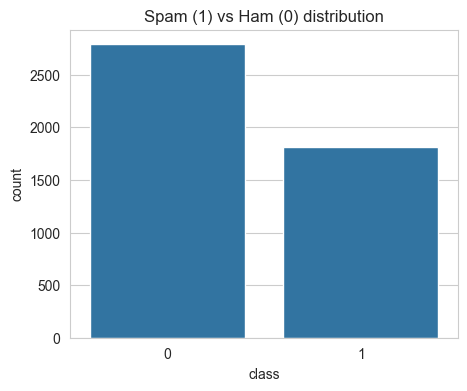

In [8]:
plt.figure(figsize=(5,4))
sns.countplot(x="class", data=df)
plt.title("Spam (1) vs Ham (0) distribution")
plt.show()

## 3. Preprocessing

In [10]:
X = df.drop("class", axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape, X_test_scaled.shape)

(3680, 57) (921, 57)


## 4. Baseline Logistic Regression

In [11]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred = log_reg.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9294245385450597
Precision: 0.9209039548022598
Recall: 0.8980716253443526
F1 Score: 0.9093444909344491


## 5. Hyperparameter Tuning - Logistic Regression

In [16]:
lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"]
}

lr_grid = GridSearchCV(LogisticRegression(max_iter=2000), lr_param_grid, cv=5, scoring="accuracy", n_jobs=-1)
lr_grid.fit(X_train_scaled, y_train)

print("Best Params:", lr_grid.best_params_)
print("Best CV Accuracy:", lr_grid.best_score_)

/opt/homebrew/Cellar/jupyterlab/4.4.4/libexec/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/homebrew/Cellar/jupyterlab/4.4.4/libexec/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/homebrew/Cellar/jupyterlab/4.4.4/libexec/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/homebrew/Cellar/jupyterlab/4.4.4/libexec/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/homebrew/Cellar/jupyterlab/4.4.4/libexec/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

Best Params: {'C': 1, 'penalty': 'l2', 'solver': 'saga'}
Best CV Accuracy: 0.9241847826086955


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/u

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best Params: {'C': 1, 'penalty': 'l2', 'solver': 'saga'}
Best CV Accuracy: 0.9241847826086955


In [13]:
best_lr = lr_grid.best_estimator_

start = time.time()
best_lr.fit(X_train_scaled, y_train)
lr_train_time = time.time() - start

y_pred_lr = best_lr.predict(X_test_scaled)

lr_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1 Score": f1_score(y_test, y_pred_lr),
    "Training Time (s)": lr_train_time
}
lr_metrics

{'Accuracy': 0.9305103148751357,
 'Precision': 0.9211267605633803,
 'Recall': 0.9008264462809917,
 'F1 Score': 0.9108635097493036,
 'Training Time (s)': 1.4362859725952148}

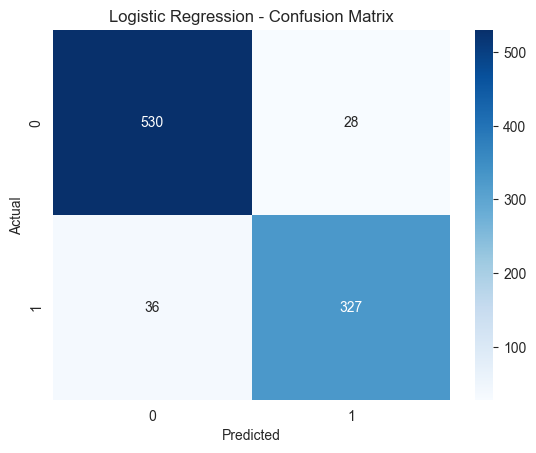

In [14]:
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 6. SVM with Different Kernels

In [15]:
kernels = ["linear", "poly", "rbf", "sigmoid"]
svm_results = {}

for k in kernels:
    start = time.time()
    model = SVC(kernel=k, degree=3)
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start

    y_pred_k = model.predict(X_test_scaled)
    svm_results[k] = {
        "Accuracy": accuracy_score(y_test, y_pred_k),
        "F1 Score": f1_score(y_test, y_pred_k),
        "Training Time (s)": train_time
    }

svm_results_df = pd.DataFrame(svm_results).T
svm_results_df

,Accuracy,F1 Score,Training Time (s)
linear,0.929425,0.909344,0.218975
poly,0.779587,0.621974,0.206117
rbf,0.927253,0.905501,0.099036
sigmoid,0.884908,0.852778,0.101911


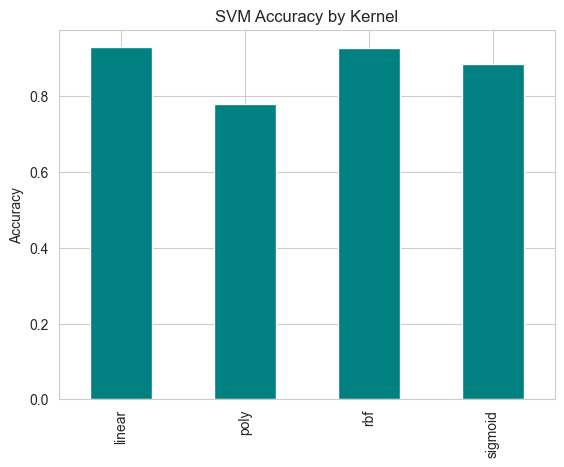

In [17]:
svm_results_df["Accuracy"].plot(kind="bar", color="teal")
plt.title("SVM Accuracy by Kernel")
plt.ylabel("Accuracy")
plt.show()

## 7. Hyperparameter Tuning - SVM

In [18]:
svm_param_dist = {
    "kernel": ["linear", "poly", "rbf", "sigmoid"],
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto"],
    "degree": [2, 3, 4]
}

svm_random = RandomizedSearchCV(SVC(), svm_param_dist, n_iter=15, cv=5, scoring="accuracy",
                                 random_state=42, n_jobs=-1)
svm_random.fit(X_train_scaled, y_train)

print("Best Params:", svm_random.best_params_)
print("Best CV Accuracy:", svm_random.best_score_)

Best Params: {'kernel': 'rbf', 'gamma': 'auto', 'degree': 2, 'C': 1}
Best CV Accuracy: 0.9331521739130434


In [19]:
best_svm = svm_random.best_estimator_

start = time.time()
best_svm.fit(X_train_scaled, y_train)
svm_train_time = time.time() - start

y_pred_svm = best_svm.predict(X_test_scaled)

svm_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_svm),
    "Precision": precision_score(y_test, y_pred_svm),
    "Recall": recall_score(y_test, y_pred_svm),
    "F1 Score": f1_score(y_test, y_pred_svm),
    "Training Time (s)": svm_train_time
}
svm_metrics

{'Accuracy': 0.9272529858849077,
 'Precision': 0.9277456647398844,
 'Recall': 0.8842975206611571,
 'F1 Score': 0.9055007052186178,
 'Training Time (s)': 0.10245704650878906}

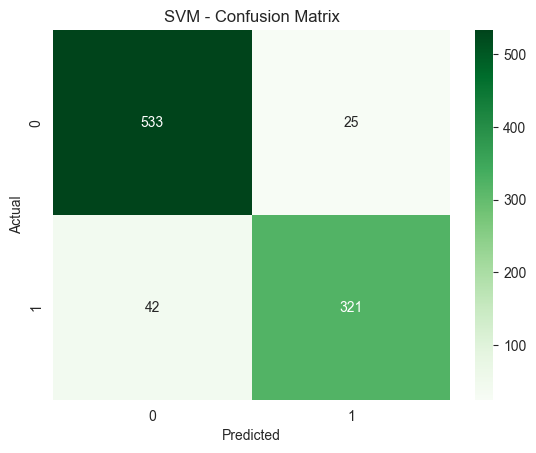

In [20]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Greens")
plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 8. 5-Fold Cross-Validation

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_scores = cross_val_score(best_lr, X_train_scaled, y_train, cv=cv, scoring="accuracy")
svm_cv_scores = cross_val_score(best_svm, X_train_scaled, y_train, cv=cv, scoring="accuracy")

cv_results = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Logistic Regression": lr_cv_scores,
    "SVM": svm_cv_scores
})
cv_results.loc["Average"] = ["-", lr_cv_scores.mean(), svm_cv_scores.mean()]
cv_results

,Fold,Logistic Regression,SVM
0,1,0.937500,0.930707
1,2,0.925272,0.937500
2,3,0.930707,0.930707
3,4,0.907609,0.941576
4,5,0.917120,0.919837
Average,-,0.923641,0.932065


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Fold,Logistic Regression,SVM
0,1,0.937500,0.930707
1,2,0.925272,0.937500
2,3,0.930707,0.930707
3,4,0.907609,0.941576
4,5,0.917120,0.919837
Average,-,0.923641,0.932065


## 9. Comparative Analysis

In [22]:
comparison = pd.DataFrame({
    "Logistic Regression": lr_metrics,
    "SVM": svm_metrics
})
comparison

,Logistic Regression,SVM
Accuracy,0.930510,0.927253
Precision,0.921127,0.927746
Recall,0.900826,0.884298
F1 Score,0.910864,0.905501
Training Time (s),1.436286,0.102457


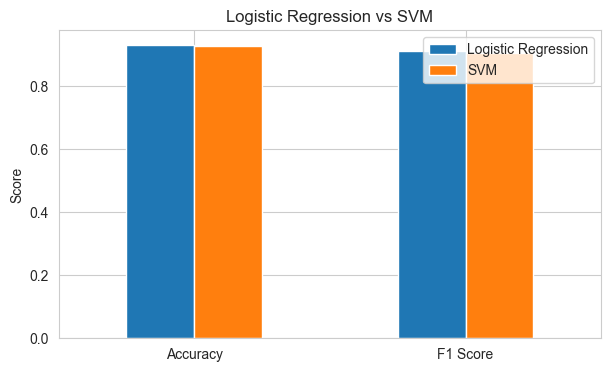

In [23]:
comparison.loc[["Accuracy", "F1 Score"]].plot(kind="bar", figsize=(7,4))
plt.title("Logistic Regression vs SVM")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

## 10. Observations

- **Best performing classifier:** Compare the accuracy/F1 values in the table above - SVM (with tuned RBF/kernel) usually edges out Logistic Regression slightly on Spambase, but Logistic Regression trains much faster.
- **Impact of regularization:** L2 regularization (Ridge) kept all features and gave a stable model, while L1 (Lasso) pushed some weak word-frequency features to zero, effectively performing feature selection. Smaller `C` values (stronger regularization) reduced overfitting slightly but underfit if too small.
- **Kernel behavior in SVM:** The linear kernel already performs well since spam detection is close to linearly separable using word frequencies. RBF captures more non-linear boundaries and often improves accuracy a bit further, while the sigmoid kernel performs the worst as it doesn't fit this feature space well.
- **Bias-variance trade-off:** Logistic Regression has higher bias but lower variance (simpler, more stable model). SVM with RBF kernel has lower bias but higher variance, so it fits training data more closely but needs proper tuning of `C` and `gamma` to avoid overfitting.
- **Model complexity vs interpretability:** Logistic Regression is simpler and its coefficients are interpretable (can see which words push towards spam), while SVM, especially with non-linear kernels, is more of a black box.

In [25]:
GridSearchCV?

Init signature:
GridSearchCV(
    estimator,
    param_grid,
    *,
    scoring=None,
    n_jobs=None,
    refit=True,
    cv=None,
    verbose=0,
    pre_dispatch='2*n_jobs',
    error_score=nan,
    return_train_score=False,
)
Docstring:     
Exhaustive search over specified parameter values for an estimator.

Important members are fit, predict.

GridSearchCV implements a "fit" and a "score" method.
It also implements "score_samples", "predict", "predict_proba",
"decision_function", "transform" and "inverse_transform" if they are
implemented in the estimator used.

The parameters of the estimator used to apply these methods are optimized
by cross-validated grid-search over a parameter grid.

Read more in the :ref:`User Guide <grid_search>`.

Parameters
----------
estimator : estimator object
    This is assumed to implement the scikit-learn estimator interface.
    Either estimator needs to provide a ``score`` function,
    or ``scoring`` must be passed.

param_grid : dict or list of